In [110]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

In [111]:
eda_univ = pd.read_csv(r"C:\Users\Jay Patel\Campusx\ml_projects\PropNavigator\data\fe\featured_properties.csv")
eda_univ

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,features,luxury_score
0,Z82002722,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,SS Linden Floors,sector 84,2.76,15333.0,1800 sqft (167.23 sqm) Carpet Area,NaN,NaN,...,0,0,0,0,1,north-east,Unfurnished,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",0.005538
1,P84485374,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,"Block E DLF City Phase 1, Gurgaon",sector 26,4.25,15741.0,"2,700 sqft (251 sqm) Carpet Area",NaN,NaN,...,0,0,0,0,0,not available,Unfurnished,New Property,NaN,0.000000
2,X83510988,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,"Sushant Lok Phase 1, Gurgaon",sector 43,5.25,13125.0,"4,000 sqft (372 sqm) Carpet Area",NaN,NaN,...,1,1,0,1,1,east,Furnished,Relatively New,"['Feng Shui / Vaastu Compliant', 'Water purifi...",0.002501
3,Q83709812,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,International City by SOBHA Phase 2,sector 109,9.00,20000.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,0,1,0,0,0,west,Unfurnished,Relatively New,"['Maintenance Staff', 'Swimming Pool', 'No ope...",0.003063
4,R84594132,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,godrej meridien,sector 106,3.11,15534.0,"2,002 sqft (186 sqm) Built-up Area",NaN,NaN,...,0,1,0,0,0,east,Unfurnished,New Property,"['Power Back-up', 'Intercom Facility', 'Lift(s...",0.003411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5975,X84830390,Independent House,https://www.99acres.com/8-bhk-bedroom-independ...,"Sector 52, Gurgaon",sector 52,5.25,58333.0,900 sqft (83.61 sqm) Plot Area,900.0,NaN,...,0,0,0,1,0,north-east,Unfurnished,New Property,"['Water Storage', 'Recently Renovated', 'Natur...",0.002046
5976,J85765480,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,Whiteland Blissville,sector 76,2.15,13000.0,"1,656 sqft (154 sqm) Super Built-up Area",NaN,1656.0,...,0,0,0,0,0,north-east,Unfurnished,New Property,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",0.007125
5977,Y85077706,Independent Builder Floor,https://www.99acres.com/2-bhk-bedroom-independ...,Signature Global Park,sector 33,0.95,9277.0,"1,024 sqft (95 sqm) Super Built-up Area",NaN,1024.0,...,0,0,0,0,0,north-east,Unfurnished,New Property,"['Water purifier', 'Centrally Air Conditioned'...",0.010188
5978,K84552310,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,Huda Flats,sector 57,3.50,13207.0,"2,650 sqft (246 sqm) Super Built-up Area",NaN,2650.0,...,0,1,0,1,0,east,Semi-Furnished,New Property,"['Centrally Air Conditioned', 'Security / Fire...",0.009143


In [3]:
eda_univ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5980 entries, 0 to 5979
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   property_id              5980 non-null   object 
 1   property_type            5980 non-null   object 
 2   link                     5980 non-null   object 
 3   society                  5980 non-null   object 
 4   sector                   5980 non-null   object 
 5   price_in_cr              5974 non-null   float64
 6   price_per_sqft           5974 non-null   float64
 7   areawithtype             5980 non-null   object 
 8   plot_area                2093 non-null   float64
 9   super_built_up_area      2792 non-null   float64
 10  built_up_area            752 non-null    float64
 11  carpet_area              1027 non-null   float64
 12  bedrooms                 5980 non-null   int64  
 13  bathrooms                5980 non-null   int64  
 14  balcony                 

In [4]:
eda_univ.isnull().sum()

property_id                   0
property_type                 0
link                          0
society                       0
sector                        0
price_in_cr                   6
price_per_sqft                6
areawithtype                  0
plot_area                  3887
super_built_up_area        3188
built_up_area              5228
carpet_area                4953
bedrooms                      0
bathrooms                     0
balcony                       0
floornum                    106
study_room                    0
servant_room                  0
store_room                    0
pooja_room                    0
others                        0
facing                        0
furnishing_type               0
age_possession_category       0
luxury_score                  0
dtype: int64

In [5]:
property_dist = eda_univ['property_type'].value_counts().reset_index()
property_dist

,property_type,count
0,Flat,2460
1,Independent House,2268
2,Independent Builder Floor,1252


In [6]:
(property_dist['count']  / eda_univ.shape[0] ) * 100

0    41.137124
1    37.926421
2    20.936455
Name: count, dtype: float64

### 1. Property Type

In [7]:
fig = px.bar(
    data_frame = property_dist,
    x = 'property_type',
    y = 'count',
    text = [f"{(count/eda_univ.shape[0])*100:.1f}%" for count in property_dist['count']]
)

fig.update_traces(textposition = 'outside') 


#### `Observations`

- `Flats are in majority (41 percent) and then houses(~37 percent) and then indepedent builder florr (~ 20 percent)`

- `No missing values`

#### 2. Society

In [8]:
eda_univ['society'].value_counts().reset_index()

,society,count
0,"Palam Vihar, Gurgaon",105
1,hero homes,79
2,"DLF Phase 2, Gurgaon",71
3,shapoorji pallonji joyville gurugram,70
4,"DLF Phase 1, Gurgaon",69
...,...,...
1043,M3M Antalya Hills,1
1044,Silverglades Tarudhan Valley Golf Resort,1
1045,"Sector 99, Gurgaon",1
1046,"Ansal, Ultra Luxury Builder Floor",1


In [9]:
eda_univ['society'].isnull().sum()

0

In [10]:
society_counts = eda_univ['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 90).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': 1,
 'High (50-100)': 14,
 'Average (10-49)': 157,
 'Low (2-9)': 390,
 'Very Low (1)': 486}

In [11]:
# top 10 societies
top_society = eda_univ[eda_univ['society'] != 'independent']['society'].value_counts().head(10).reset_index()
top_society

,society,count
0,"Palam Vihar, Gurgaon",105
1,hero homes,79
2,"DLF Phase 2, Gurgaon",71
3,shapoorji pallonji joyville gurugram,70
4,"DLF Phase 1, Gurgaon",69
5,Ansals Palam Vihar,67
6,dlf the ultima,65
7,Emaar MGF Marbella,58
8,godrej meridien,57
9,m3m heights,56


In [12]:
fig1 = px.bar(
    data_frame= top_society
    , x = 'society'
    , y = 'count'
    , text ='count' 
            )
fig1

### 3. Sector

In [13]:
eda_univ['sector'].value_counts().reset_index()

,sector,count
0,sector 43,262
1,sector 1,219
2,sector 26,207
3,sector 50,204
4,sector 57,185
...,...,...
97,sector 80,2
98,sector 78,2
99,sector 18,1
100,sector 101,1


In [14]:
top_sector = eda_univ['sector'].value_counts().reset_index().head(10)
top_sector

,sector,count
0,sector 43,262
1,sector 1,219
2,sector 26,207
3,sector 50,204
4,sector 57,185
5,sector 102,182
6,sector 67,182
7,sector 65,175
8,sector 33,171
9,sector 104,163


In [15]:
fig2 = px.bar(data_frame = top_sector, x ='sector', y = 'count',text='count')
fig2

In [16]:
# Frequency distribution for sectors

sector_counts = eda_univ['sector'].value_counts()

sector_frequency_bins = {
    
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': 21,
 'High (50-100)': 21,
 'Average (10-49)': 42,
 'Low (2-9)': 15,
 'Very Low (1)': 3}

### 4. Price

In [17]:
eda_univ['price_in_cr'].describe()

count    5974.000000
mean        5.334066
std         5.283274
min         0.170000
25%         2.280000
50%         3.450000
75%         6.490000
max        80.000000
Name: price_in_cr, dtype: float64

`Observations :`

- `Maximum price (in cr) is going up to 80 Cr. Looks Interesting!`

- `Average price of the properties is at distance from medium price. Might be some high pricing properties/villas dominating the distributions. Definitely some outliers on the higher side as 50th and 75th percentile properties are at  3 Cr and 6 Cr respectively `

- `Descriptive Statistics:`

    - `Count: There are 5974 non-missing price entries.`

    - `Mean Price: The average price is approximately 5.33 crores.`

    - `Median Price: The median (or 50th percentile) price is 3.45 crores.`

    - `Standard Deviation: The prices have a standard deviation of 5.28, indicating variability in the prices.`

    - `Range: Prices range from a minimum of 0.17 crores to a maximum of 80 crores.`

    - `IQR: The interquartile range (difference between 75th and 25th percentile) is from 2.25 crores to 6.49 crores.`

In [18]:
eda_univ['price_in_cr'].isnull().sum()

6

In [19]:
fig3 = px.histogram(eda_univ['price_in_cr'],)
fig3

In [20]:
fig4 = px.box(data_frame= eda_univ, x='price_in_cr')
fig4

`- Visualizations:`

    - Distribution: The histogram indicates that most properties are priced in the lower range (below 13 crores), with a few properties going beyond 20 crores.`

    - `Box Plot: The box plot showcases the spread of the data and potential outliers.
    
     Properties priced above approximately 13 crores might be considered outliers as they lie beyond the upper whisker of the box plot.`
 

In [21]:
# Skewness and Kurtosis

skewness = eda_univ['price_in_cr'].skew()
kurtosis = eda_univ['price_in_cr'].kurt()

print(skewness,kurtosis)

2.9791854435833347 16.127604736480496


`**Skewness**: The price distribution has a skewness of approximately 3, indicating a positive skew. This means that the distribution of tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.`

`**Kurtosis**: The kurtosis value is approximately 16. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.`

In [22]:
# Quantile Analysis

quantiles = eda_univ['price_in_cr'].quantile([0.01, 0.05, 0.50, 0.95, 0.99])

quantiles

0.01     0.5800
0.05     1.1565
0.50     3.4500
0.95    16.0000
0.99    25.0000
Name: price_in_cr, dtype: float64

`Quantile Analysis:`

- `1% Quantile: Only 1% of properties are priced below 0.58 crores.`
- `5% Quantile: 5% of properties are priced below 1.15 crores.`
- `50% Quantile: 50% of properties are prices below 3.45 crores.`
- `95% Quantile: 95% of properties are priced below 16 crores.`
- `99% Quantile: 99% of properties are priced below 25 crores, indicating that very few properties are priced above this value.`

In [23]:
# Identify potential outliers using IQR method

Q1 = np.quantile(eda_univ['price_in_cr'].dropna(), 0.25)
Q3 = np.quantile(eda_univ['price_in_cr'].dropna(), 0.75)

IQR = Q3 - Q1

IQR

4.210000000000001

In [24]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-4.035000000000002 12.805000000000001


In [25]:
outliers = eda_univ[(eda_univ['price_in_cr'] < lower_bound) | (eda_univ['price_in_cr'] > upper_bound)]
outliers.shape

(516, 25)

In [26]:
outliers['price_in_cr'].describe()

count    516.000000
mean      18.889709
std        6.539067
min       12.840000
25%       14.837500
50%       17.000000
75%       21.000000
max       80.000000
Name: price_in_cr, dtype: float64

`Outliers Analysis (using IQR method):`

- `Based on the IQR method, there are 516 properties considered as outliers.`

- `These outliers have an average price of approximately 18 crores.`

- `The range for these outliers is from 12 crores to 80 crores.`

In [27]:
outliers

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,floornum,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,luxury_score
9,I84940266,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,Emaar MGF The Vilas,sector 24,21.00,583333.0,360 sqft (33.45 sqm) Plot Area | 6800 sqft (63...,360.0,NaN,...,2.0,1,1,1,1,0,east,Furnished,Relatively New,0.007612
11,Z84139124,Independent House,https://www.99acres.com/8-bhk-bedroom-independ...,"DLF Phase 2, Gurgaon",sector 25,16.00,33333.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,3.0,1,1,0,1,1,east,Semi-Furnished,Relatively New,0.002109
36,S84944800,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,Unitech Espace,sector 50,15.00,46296.0,3240 sqft (301.01 sqm) Plot Area,3240.0,NaN,...,2.0,1,1,1,1,0,east,Unfurnished,Relatively New,0.003879
40,L81657752,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,Unitech Nirvana Birch Court,sector 50,20.00,44444.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,1.0,0,1,0,0,0,east,Semi-Furnished,Old Property,0.005254
43,E84700914,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,Emaar MGF Marbella,sector 66,16.00,50794.0,3150 sqft (292.64 sqm) Plot Area,3150.0,NaN,...,3.0,1,1,0,0,0,north-east,Semi-Furnished,Relatively New,0.005838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5923,V82811486,Flat,https://www.99acres.com/4-bhk-bedroom-apartmen...,salcon the verandas,sector 54,19.85,33661.0,"5,986 sqft (556 sqm) Super Built-up Area",NaN,5986.0,...,17.0,0,1,0,1,0,north-west,Furnished,Old Property,0.011173
5925,N84063534,Independent House,https://www.99acres.com/9-bhk-bedroom-independ...,Luxurious villa 12mtr east facing park facing,sector 24,17.00,37778.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,3.0,1,1,1,1,0,east,Furnished,Relatively New,0.004002
5942,I84167596,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,International City by SOBHA Phase 2,sector 109,14.00,38889.0,3600 sqft (334.45 sqm) Plot Area,3600.0,NaN,...,2.0,0,1,1,0,0,north,Semi-Furnished,Relatively New,0.006234
5949,J84742264,Independent House,https://www.99acres.com/6-bhk-bedroom-independ...,Emaar MGF Marbella,sector 66,25.00,55556.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,0.0,1,1,0,1,1,east,Furnished,Moderately Old,0.001860


In [28]:
fig5 = px.histogram(data_frame= outliers['price_in_cr'])
fig5

In [29]:
# Price Binnings

bins = [0, 1, 2, 3, 5, 10, 15, 20, 30, 35, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-15","15-20","20-30","30-35", "35-50"]


price_counts = pd.cut(
    eda_univ['price_in_cr'], 
    bins=bins, 
    labels=bin_labels
).value_counts().sort_index()


price_binnings = price_counts.reset_index()
price_binnings.columns = ["price_in_cr", "count"]


price_binnings["percentage"] = (price_binnings["count"] / price_binnings["count"].sum()) * 100

price_binnings


,price_in_cr,count,percentage
0,0-1,256,4.287389
1,1-2,946,15.843242
2,2-3,1361,22.793502
3,3-5,1502,25.154915
4,5-10,1112,18.623346
5,10-15,455,7.620164
6,15-20,194,3.249037
7,20-30,128,2.143695
8,30-35,9,0.150729
9,35-50,8,0.133981


In [30]:
fig6 = px.bar(data_frame = price_binnings, x = 'price_in_cr', y ='count', text = 'count')
fig6

#### `Observations`

- `The majority of properties are priced in the "0-5 crores" ranges.`

- `There's a significant drop in the number of properties priced above "5-10 crores Range.`

#### ECDF Plot (Empirical Cumulative Distribution Function)

- The ECDF plot (Empirical Cumulative Distribution Function) is a powerful alternative to histograms or KDE plots for visualizing the distribution of a variable — especially useful when comparing raw vs transformed variables or identifying outliers and skewness.

What Is an ECDF Plot?

- An ECDF plot shows the proportion of data points less than or equal to a given value.

 Key Characteristics:

- X-axis: Sorted data values

- Y-axis: Cumulative proportion of observations



In [31]:
ecdf = eda_univ['price_in_cr'].value_counts().sort_index().cumsum() / len(eda_univ)
ecdf.reset_index()

,price_in_cr,count
0,0.17,0.000167
1,0.19,0.000334
2,0.20,0.000502
3,0.24,0.000669
4,0.25,0.000836
...,...,...
723,46.00,0.998328
724,48.00,0.998495
725,55.00,0.998662
726,57.00,0.998829


In [32]:
fig = px.ecdf(eda_univ, x='price_in_cr')

fig.update_layout(
    title='ECDF of Property Prices',
    xaxis_title='Price (in Cr)',
    yaxis_title='Proportion of Properties ≤ Price',
    template='plotly_white'    
)

fig.show()

### Observation

- 85 % of the datapoints are lying below or equal to 10 Cr Price.

- The steep rise early on suggests most properties are priced under ₹0-5 crore.

- The curve flattens near 1.0, meaning only a few properties are very expensive (e.g., ₹20–30 crore range).



#### Log Transformation

In [33]:
fig = px.histogram(eda_univ['price_in_cr'])
fig

In [34]:
fig = px.histogram(np.log1p(eda_univ['price_in_cr']))
fig

- Used log 1p because by taking normal log i'm getting negetive values as well.

In [35]:
fig = make_subplots(rows=1, cols=2, subplot_titles=[
    'Distribution of Prices (Original)',
    'Distribution of Prices (Log Transformed)'
])


fig.add_trace(
    go.Histogram(
        x=eda_univ['price_in_cr'],
        nbinsx=50,
        marker_color='blue',
        name='Original Price'
    ),
    row=1, col=1
)

# Log-Transformed Price Histogram
fig.add_trace(
    go.Histogram(
        x=np.log1p(eda_univ['price_in_cr']),
        nbinsx=50,
        marker_color='green',
        name='Log Transformed Price'
    ),
    row=1, col=2
)

# Update layout
fig.update_layout(
    title_text='Side-by-Side Distribution of Prices',
    height=500,
    width=1000,
    showlegend=False
)

# Add axis labels
fig.update_xaxes(title_text='Price (in Crores)', row=1, col=1)
fig.update_yaxes(title_text='Frequency', row=1, col=1)
fig.update_xaxes(title_text='Log(Price)', row=1, col=2)
fig.update_yaxes(title_text='Frequency', row=1, col=2)

fig.show()


np.log1p(x): This function computes the natural logarithm of 1+x. 

It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

### Box Plot Transformations

In [36]:
fig = make_subplots(
    rows=1, 
    cols=2, 
    subplot_titles= ['Distribution of Prices (Original)',
    'Distribution of Prices (Log Transformed)'])

fig.add_trace(go.Box(
    x = eda_univ['price_in_cr'])
    , row = 1
    , col = 1)

fig.add_trace(go.Box(
    x = np.log1p(eda_univ['price_in_cr']))
    , row = 1
    , col = 2)

# Update layout

fig.update_layout(
    title_text='Side-by-Side Distribution of Prices',
    height=500,
    width=1000,
    showlegend=False
)

# Add axis labels
fig.update_xaxes(title_text='Price (in Crores)', row=1, col=1)
fig.update_yaxes(title_text='Frequency', row=1, col=1)
fig.update_xaxes(title_text='Log(Price)', row=1, col=2)
fig.update_yaxes(title_text='Frequency', row=1, col=2)

fig.show()

#### `Observations :`

`Original Price Distribution :`

- `The median is much closer to the bottom of the box and upper whisker is much longer. This suggests that most of the property prices are on the lower end with long tail of heavy prices.`

- `We can see the several dots outside the upper whisker marker suggesting heavy presence of outliers or extremely expensive properties.`


`Log transformed Price Distribution :`

- `The box is more centered with median line closer to the middle. This shows that log transformation compressed the high prices and pulled the distribution closer to normal distribution`

- `The number and distance of outliers dots is much smaller and this is due to log transformation as it shrinks the scale, reducing the gap between very high and moderate prices.`

- `The log transformed distribution reduces skewness and variance making data more suitable for modelling.`

### 5. Price Per Square Feet

In [37]:
eda_univ['price_per_sqft'].describe()

count      5974.000000
mean      24530.206394
std       35096.103999
min        1815.000000
25%       12389.500000
50%       16244.000000
75%       27296.000000
max      750000.000000
Name: price_per_sqft, dtype: float64

#### `Observations`:

- `Minium Value is at 1815 per sqft, which seems reasonalble.`

- `Maximum Value is at 750000 per sqft which is quite huge and can't be true. Even the most luxuriaous villas or penthhouse in the premium cities like New York , Beijing or Mumbai does't cost this much. So again something is off with those high values as well.`

- `I can sense some outliers as well on the higher sider as 50th and 75th percentile values are below 16k and 27k.`


1. `Extremely High Values :`

- `7,50,000 per sqft is insanely high especially when :`

    - `75% of properties are below ~ 27 K`

    - `Median is just ~ 16 k`

- `This means we have extreme outlier - might be data error as 7,50,000 per sqft is way more expenside . Even the most costly cities like New York doesn't have this much per sqft rate so definately something wrong going on in price per sqft column.`

2. `Mean > Median --> Positive Skew`

- `Mean = ~ 24 k and Median = ~ 16 k `

- `Mean is pulled up by high values, it confirms a right skewed distributions - possible driver by few outrageously high price point like 7,50,000.`

3. `Very High Standard Deviation `

- `Standard deviation is more than 1.4 times then the mean suggesting huge variability in price per sqft column`


In [38]:
eda_univ['price_per_sqft'].isnull().sum()

6

In [39]:
eda_univ['price_per_sqft'].value_counts().reset_index()

,price_per_sqft,count
0,11111.0,29
1,20000.0,28
2,44444.0,27
3,10000.0,26
4,16666.0,24
...,...,...
3815,14991.0,1
3816,7259.0,1
3817,10645.0,1
3818,21898.0,1


In [40]:
fig = px.histogram(data_frame= eda_univ, x = 'price_per_sqft')
fig

In [41]:
fig = px.box(data_frame= eda_univ, x ='price_per_sqft')
fig

`Observations :`

- `Most properties have a price_per_sqft ranging between approximately ₹1815 and ₹30,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.`

- `The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers`

- `Potential Outliers`

- `Right Skewed`


### 6. bedRoom

In [42]:
eda_univ['bedrooms']

0       4
1       3
2       4
3       4
4       3
       ..
5975    8
5976    3
5977    2
5978    4
5979    4
Name: bedrooms, Length: 5980, dtype: int64

In [43]:
eda_univ['bedrooms'].isnull().sum()

0

In [44]:
bedroom_count = eda_univ['bedrooms'].value_counts().sort_index().reset_index()
bedroom_count

,bedrooms,count
0,1,28
1,2,629
2,3,2304
3,4,1768
4,5,520
5,6,285
6,7,80
7,8,79
8,9,85
9,10,53


In [45]:
px.bar(data_frame= bedroom_count, x = 'bedrooms', y = 'count', text= 'count')

In [46]:
bedroom_pie = round((eda_univ['bedrooms'].value_counts(normalize= True).head() * 100),2).sort_index().reset_index()
bedroom_pie

,bedrooms,proportion
0,2,10.52
1,3,38.53
2,4,29.57
3,5,8.70
4,6,4.77


In [47]:
fig = px.pie(
    data_frame=bedroom_pie,
    names='bedrooms',
    values='proportion',
    hover_data=['proportion'],
)

# Add exact labels from the dataframe
fig.update_traces(
    textinfo='label+text',
    text=bedroom_pie['proportion'].astype(str) + '%'
)

fig.show()


### 7. bathroom

In [48]:
eda_univ['bathrooms'].isnull().sum()

0

In [49]:
bathroom_count = eda_univ['bathrooms'].value_counts().sort_index().reset_index()
bathroom_count

,bathrooms,count
0,1,40
1,2,795
2,3,1757
3,4,1782
4,5,639
5,6,442
6,7,152
7,8,98
8,9,92
9,10,39


In [50]:
px.bar(data_frame= bathroom_count, x = 'bathrooms', y = 'count', text= 'count')

In [51]:
bathroom_pie = round((eda_univ['bathrooms'].value_counts(normalize= True).head() * 100),2).sort_index().reset_index()
bathroom_pie

,bathrooms,proportion
0,2,13.29
1,3,29.38
2,4,29.80
3,5,10.69
4,6,7.39


In [52]:
fig = px.pie(data_frame = bathroom_pie,names = 'bathrooms'
             , values = 'proportion'
             , hover_data= ['proportion'])

fig.update_traces(
        textinfo = 'label+text'
       ,text = bathroom_pie['proportion'].astype(str) + "%"
)

### 8. balcony

In [53]:
eda_univ['balcony'].isnull().sum()

0

In [54]:
balcony_count = eda_univ['balcony'].value_counts().sort_index().reset_index()
balcony_count

,balcony,count
0,0,102
1,1,259
2,2,2109
3,3,1484
4,3+,2026


In [55]:
px.bar(data_frame = balcony_count, x = 'balcony', y = 'count', text= 'count')

In [56]:
balcony_pie = round((eda_univ['balcony'].value_counts(normalize= True) * 100),2).sort_index().reset_index()
balcony_pie

,balcony,proportion
0,0,1.71
1,1,4.33
2,2,35.27
3,3,24.82
4,3+,33.88


In [57]:
fig = px.pie(data_frame = balcony_pie, names = 'balcony', values = 'proportion', hover_data= ['proportion'])

fig.update_traces(
    textinfo ='label+text'
    , text = balcony_pie['proportion'].astype(str) + "%"
)

### 9. floorNum

In [58]:
eda_univ['floornum'].isnull().sum()

106

In [59]:
eda_univ['floornum'].describe()

count    5874.00000
mean        5.59874
std         5.68279
min        -1.00000
25%         2.00000
50%         3.00000
75%         8.00000
max        45.00000
Name: floornum, dtype: float64

In [60]:
floornum_count = eda_univ['floornum'].value_counts().reset_index().head()
floornum_count

,floornum,count
0,2.0,1241
1,3.0,1157
2,1.0,714
3,4.0,632
4,5.0,206


In [61]:
px.bar(floornum_count, x = 'floornum', y = 'count', text= 'count')

In [62]:
fig = px.box(x = eda_univ['floornum'])
fig

### 10. Facing

In [63]:
eda_univ['facing'].isnull().sum()

0

In [64]:
facing_count = eda_univ['facing'].value_counts().reset_index()
facing_count

,facing,count
0,east,1644
1,north-east,1500
2,north,922
3,not available,557
4,west,468
5,north-west,321
6,south-east,224
7,south,202
8,south-west,142


In [65]:
px.bar(data_frame = facing_count, x = 'facing', y = 'count', text = 'count')

### 11. agePossession

In [66]:
eda_univ['age_possession_category']

0         New Property
1         New Property
2       Relatively New
3       Relatively New
4         New Property
             ...      
5975      New Property
5976      New Property
5977      New Property
5978      New Property
5979    Relatively New
Name: age_possession_category, Length: 5980, dtype: object

In [67]:
eda_univ['age_possession_category'].value_counts()

age_possession_category
Relatively New        2394
New Property          1585
Moderately Old        1197
Old Property           684
Undefined              110
Under Construction      10
Name: count, dtype: int64

In [68]:
eda_univ['age_possession_category'].isnull().sum()

0

In [69]:
age_possession_top_five = eda_univ['age_possession_category'].value_counts().reset_index()
age_possession_top_five

,age_possession_category,count
0,Relatively New,2394
1,New Property,1585
2,Moderately Old,1197
3,Old Property,684
4,Undefined,110
5,Under Construction,10


In [70]:
fig = px.bar(data_frame= age_possession_top_five, x = 'age_possession_category', y ='count', text = 'count')
fig

### 12. Super Built Up Area

In [71]:
eda_univ['super_built_up_area'].isnull().sum()

3188

In [72]:
eda_univ['super_built_up_area'].describe()

count     2792.000000
mean      2242.897923
std        922.412092
min        300.000000
25%       1683.750000
50%       2000.000000
75%       2650.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [73]:
fig = px.histogram(eda_univ['super_built_up_area'].dropna())
fig

In [74]:
fig = px.box(x = eda_univ['super_built_up_area'].dropna())
fig

- Most properties have a Super built-up area ranging roughly between 300 sq.ft and 4000 sq.ft.

- There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.

In [75]:
eda_univ[eda_univ['super_built_up_area'] < 1000]

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,floornum,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,luxury_score
143,W86177258,Independent Builder Floor,https://www.99acres.com/2-bhk-bedroom-independ...,Signature Global Park,sector 33,0.75,9124.0,822 sqft (76 sqm) Super Built-up Area,NaN,822.0,...,1.0,0,0,0,0,1,north-east,Unfurnished,Relatively New,0.002501
544,N84980718,Flat,https://www.99acres.com/2-bhk-bedroom-apartmen...,signature the serenas,sector 33,0.65,9923.0,655 sqft (61 sqm) Super Built-up Area,NaN,655.0,...,12.0,0,0,0,0,0,east,Unfurnished,New Property,0.003954
822,G85121852,Flat,https://www.99acres.com/2-bhk-bedroom-apartmen...,jnu aravali apartment,sector 56,1.50,15306.0,980 sqft (91 sqm) Super Built-up Area,NaN,980.0,...,2.0,0,0,0,1,0,east,Unfurnished,Old Property,0.008629
936,G84860186,Flat,https://www.99acres.com/2-bhk-bedroom-apartmen...,pivotal devaan,sector 84,0.60,10291.0,583 sqft (54 sqm) Super Built-up Area,NaN,583.0,...,8.0,0,0,0,0,1,west,Unfurnished,Relatively New,0.002374
956,N74559517,Independent Builder Floor,https://www.99acres.com/2-bhk-bedroom-independ...,Signature Global Park,sector 33,0.80,15661.0,822 sqft (76 sqm) Super Built-up Area,NaN,822.0,...,3.0,0,0,0,0,0,north-east,Unfurnished,New Property,0.003182
1171,A84470990,Flat,https://www.99acres.com/2-bhk-bedroom-apartmen...,mahindra aura,sector 110,1.45,14646.0,990 sqft (92 sqm) Super Built-up Area,NaN,990.0,...,8.0,0,0,0,0,0,east,Unfurnished,Moderately Old,0.002959
1387,C84357414,Flat,https://www.99acres.com/1-bhk-bedroom-apartmen...,cosmos express 99,sector 99,0.87,17490.0,795 sqft (74 sqm) Super Built-up Area,NaN,795.0,...,4.0,0,0,0,0,0,east,Unfurnished,New Property,0.002846
1403,B85360022,Flat,https://www.99acres.com/2-bhk-bedroom-apartmen...,signature global the millennia,sector 37,0.72,13043.0,850 sqft (79 sqm) Super Built-up Area,NaN,850.0,...,6.0,0,0,0,0,0,east,Unfurnished,Relatively New,0.002644
1453,P85291010,Flat,https://www.99acres.com/2-bhk-bedroom-apartmen...,pyramid urban homes,sector 70,0.72,8648.0,836 sqft (78 sqm) Super Built-up Area,NaN,836.0,...,5.0,0,0,0,0,0,north-east,Unfurnished,Relatively New,0.003752
1622,Z83891026,Flat,https://www.99acres.com/2-bhk-bedroom-apartmen...,shapoorji pallonji joyville gurugram,sector 102,1.52,16612.0,915 sqft (85 sqm) Super Built-up Area,NaN,915.0,...,11.0,0,0,0,0,0,north,Unfurnished,Relatively New,0.005048


In [76]:
suspicious_super_built_up = eda_univ[eda_univ['super_built_up_area'] < 1000]

In [77]:
eda_univ[eda_univ['super_built_up_area']< 500]

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,floornum,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,luxury_score
4478,E85957768,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,"Block M DLF phase 2, Gurgaon",sector 25,6.50,161691.0,402 sqft (37 sqm) Super Built-up Area,NaN,402.0,...,3.0,0,1,0,0,0,not available,Unfurnished,New Property,0.000706
5530,T85265648,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,Oriental Homes,sector 57,3.95,131666.0,300 sqft (28 sqm) Super Built-up Area,NaN,300.0,...,4.0,1,1,0,1,0,west,Unfurnished,New Property,0.005022


### 13. Built Up Area

In [78]:
eda_univ['built_up_area'].value_counts()

built_up_area
2700.0    26
2430.0    22
4500.0    19
1800.0    19
3240.0    17
          ..
3900.0     1
2070.0     1
4100.0     1
1530.0     1
4450.0     1
Name: count, Length: 321, dtype: int64

In [79]:
eda_univ['built_up_area'].isnull().sum()

5228

In [80]:
fig = px.histogram(x = eda_univ['built_up_area'], nbins= 30)
fig

In [81]:
fig = px.box(x = eda_univ['built_up_area'].dropna())
fig

In [82]:
eda_univ['built_up_area'].describe()

count      752.000000
mean      3141.303191
std       3760.637492
min        150.000000
25%       1608.250000
50%       2402.000000
75%       3622.500000
max      76500.000000
Name: built_up_area, dtype: float64

In [83]:
eda_univ[eda_univ['built_up_area']< 500]

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,floornum,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,luxury_score
462,Q84181586,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,urban homes,sector 105,0.79,17555.0,450 sqft (41.81 sqm) Plot Area | 460 sqft (42....,450.0,NaN,...,2.0,0,0,0,0,1,east,Unfurnished,Undefined,0.000249
528,C81942078,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"Gurgaon Village, Gurgaon",sector 6,0.50,29412.0,170 sqft (15.79 sqm) Built-up Area,NaN,NaN,...,1.0,0,0,0,0,0,not available,Unfurnished,Undefined,0.000000
1155,M84498278,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"Dayanand Colony, Gurgaon",sector 6,2.38,97142.0,245 sqft (22.76 sqm) Built-up Area,NaN,NaN,...,1.0,0,0,0,0,0,not available,Furnished,Moderately Old,0.000000
1726,Q84236884,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,"Sector 46, Gurgaon",sector 46,5.50,458333.0,160 sqft (14.86 sqm) Plot Area | 150 sqft (13....,160.0,NaN,...,3.0,0,0,0,0,0,north,Unfurnished,Relatively New,0.003716
2707,G84875264,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,sector 17,sector 17,1.35,42857.0,315 sqft (29.26 sqm) Plot Area | 315 sqft (29....,315.0,NaN,...,3.0,0,0,1,0,0,north,Unfurnished,Old Property,0.003069
2827,L81936878,Independent House,https://www.99acres.com/11-bhk-bedroom-indepen...,South city -1,sector 41,3.35,62037.0,540 sqft (50.17 sqm) Plot Area | 400 sqft (37....,540.0,NaN,...,4.0,0,1,0,1,0,east,Unfurnished,New Property,0.000978
4024,C84559362,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,"Surat Nagar Phase 1, Gurgaon",sector 104,0.42,9230.0,455 sqft (42.27 sqm) Plot Area | 465 sqft (43....,455.0,NaN,...,1.0,0,0,0,0,1,west,Unfurnished,Moderately Old,0.000508
4124,V83794316,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,"Block C, Sushant Lok Phase 1, Gurgaon",sector 43,4.80,320000.0,150 sqft (13.94 sqm) Built-up Area,NaN,NaN,...,1.0,0,0,0,1,0,north,Unfurnished,Old Property,0.002248
4420,O84955876,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,"Sadar Bazar, Gurgaon",sector 12,1.50,33333.0,450 sqft (41.81 sqm) Built-up Area,NaN,NaN,...,1.0,0,0,0,0,0,not available,Unfurnished,Undefined,0.000000


In [84]:
eda_univ[eda_univ['built_up_area']>=10000]

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,floornum,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,luxury_score
2476,Y83934748,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,Adani Samsara Avasa,sector 63,4.3,2172.0,2700 sqft (250.84 sqm) Plot Area | 22500 sqft ...,2700.0,NaN,...,3.0,0,1,0,1,1,east,Furnished,Undefined,0.008978
5008,T84187970,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,Tata Primanti,sector 72,16.0,2091.0,3240 sqft (301.01 sqm) Plot Area | 76500 sqft ...,3240.0,NaN,...,4.0,1,1,1,1,0,north-east,Semi-Furnished,Moderately Old,0.009861
5010,B63658124,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,Anant Raj Manor Villas,sector 63,10.5,37037.0,2700 sqft (250.84 sqm) Plot Area | 46800 sqft ...,2700.0,NaN,...,3.0,0,1,0,0,0,north-west,Unfurnished,Relatively New,0.008387


### 14. Carpet Area

In [85]:
eda_univ['carpet_area'].describe()

count     1027.000000
mean      2700.707887
std       3156.133660
min        120.000000
25%       1600.000000
50%       2286.000000
75%       3079.000000
max      61200.000000
Name: carpet_area, dtype: float64

In [86]:
eda_univ['carpet_area'].value_counts()

carpet_area
2700.0    67
3240.0    26
4500.0    25
2430.0    21
2160.0    20
          ..
1407.0     1
684.0      1
1699.0     1
1737.0     1
598.0      1
Name: count, Length: 371, dtype: int64

In [87]:
fig = px.histogram(x = eda_univ['carpet_area'], nbins= 30)
fig

In [88]:
fig = px.box(x = eda_univ['carpet_area'].dropna())
fig

In [89]:
eda_univ[eda_univ['carpet_area']<500]

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,floornum,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,luxury_score
249,A83237992,Flat,https://www.99acres.com/1-bhk-bedroom-apartmen...,central park flower valley aqua front towers,sector 33,1.50,32894.0,456 sqft (42 sqm) Carpet Area,NaN,NaN,...,6.0,0,0,0,0,0,north,Furnished,New Property,0.010125
255,M84755814,Independent House,https://www.99acres.com/6-bhk-bedroom-independ...,"Maruti Kunj, Gurgaon",sector 105,0.49,9074.0,540 sqft (50.17 sqm) Plot Area | 540 sqft (50....,540.0,NaN,...,3.0,0,0,0,0,0,north,Unfurnished,Relatively New,0.002141
462,Q84181586,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,urban homes,sector 105,0.79,17555.0,450 sqft (41.81 sqm) Plot Area | 460 sqft (42....,450.0,NaN,...,2.0,0,0,0,0,1,east,Unfurnished,Undefined,0.000249
755,D81046933,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,urban Home,sector 105,0.85,16343.0,520 sqft (48.31 sqm) Plot Area | 510 sqft (47....,520.0,NaN,...,2.0,0,0,0,0,0,east,Unfurnished,New Property,0.001442
951,Z81946886,Independent House,https://www.99acres.com/7-bhk-bedroom-independ...,"Sector 31, Gurgaon",sector 31,1.20,13483.0,890 sqft (82.68 sqm) Plot Area | 400 sqft (37....,890.0,NaN,...,3.0,0,0,0,0,0,east,Unfurnished,Old Property,0.000000
1432,Z81057669,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,urban home,sector 105,0.65,12955.0,500 sqft (46.45 sqm) Plot Area | 520 sqft (48....,500.0,NaN,...,2.0,0,0,0,0,0,east,Unfurnished,New Property,0.000521
1434,N83110558,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,indipendent house,sector 105,0.35,7777.0,450 sqft (41.81 sqm) Plot Area | 500 sqft (46....,450.0,NaN,...,1.0,0,0,0,0,0,not available,Unfurnished,Relatively New,0.000000
1726,Q84236884,Independent House,https://www.99acres.com/2-bhk-bedroom-independ...,"Sector 46, Gurgaon",sector 46,5.50,458333.0,160 sqft (14.86 sqm) Plot Area | 150 sqft (13....,160.0,NaN,...,3.0,0,0,0,0,0,north,Unfurnished,Relatively New,0.003716
2707,G84875264,Independent House,https://www.99acres.com/3-bhk-bedroom-independ...,sector 17,sector 17,1.35,42857.0,315 sqft (29.26 sqm) Plot Area | 315 sqft (29....,315.0,NaN,...,3.0,0,0,1,0,0,north,Unfurnished,Old Property,0.003069
2827,L81936878,Independent House,https://www.99acres.com/11-bhk-bedroom-indepen...,South city -1,sector 41,3.35,62037.0,540 sqft (50.17 sqm) Plot Area | 400 sqft (37....,540.0,NaN,...,4.0,0,1,0,1,0,east,Unfurnished,New Property,0.000978


In [90]:
eda_univ[eda_univ['carpet_area']>10000]

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,floornum,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,luxury_score
1529,M83943126,Independent House,https://www.99acres.com/6-bhk-bedroom-independ...,Sector 9,sector 9,1.78,9888.0,1800 sqft (167.23 sqm) Plot Area | 12444 sqft ...,1800.0,NaN,...,1.0,0,0,0,0,0,north,Unfurnished,Relatively New,0.002610
2476,Y83934748,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,Adani Samsara Avasa,sector 63,4.30,2172.0,2700 sqft (250.84 sqm) Plot Area | 22500 sqft ...,2700.0,NaN,...,3.0,0,1,0,1,1,east,Furnished,Undefined,0.008978
2582,J84959088,Independent House,https://www.99acres.com/5-bhk-bedroom-independ...,Emaar MGF Marbella,sector 66,18.00,57143.0,3150 sqft (292.64 sqm) Plot Area | 58500 sqft ...,3150.0,NaN,...,3.0,1,1,1,1,0,north-west,Furnished,Relatively New,0.009861
4520,B83315966,Independent House,https://www.99acres.com/8-bhk-bedroom-independ...,"Sector 45, Gurgaon",sector 45,7.30,39660.0,171 sqft (15.89 sqm) Plot Area | 35521 sqft (3...,171.0,NaN,...,3.0,0,1,0,1,0,south-east,Unfurnished,Moderately Old,0.002109
5008,T84187970,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,Tata Primanti,sector 72,16.00,2091.0,3240 sqft (301.01 sqm) Plot Area | 76500 sqft ...,3240.0,NaN,...,4.0,1,1,1,1,0,north-east,Semi-Furnished,Moderately Old,0.009861


### 13.additional rooms

In [91]:
eda_univ

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,floornum,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,luxury_score
0,Z82002722,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,SS Linden Floors,sector 84,2.76,15333.0,1800 sqft (167.23 sqm) Carpet Area,NaN,NaN,...,4.0,0,0,0,0,1,north-east,Unfurnished,New Property,0.005538
1,P84485374,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,"Block E DLF City Phase 1, Gurgaon",sector 26,4.25,15741.0,"2,700 sqft (251 sqm) Carpet Area",NaN,NaN,...,1.0,0,0,0,0,0,not available,Unfurnished,New Property,0.000000
2,X83510988,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,"Sushant Lok Phase 1, Gurgaon",sector 43,5.25,13125.0,"4,000 sqft (372 sqm) Carpet Area",NaN,NaN,...,4.0,1,1,0,1,1,east,Furnished,Relatively New,0.002501
3,Q83709812,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,International City by SOBHA Phase 2,sector 109,9.00,20000.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,2.0,0,1,0,0,0,west,Unfurnished,Relatively New,0.003063
4,R84594132,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,godrej meridien,sector 106,3.11,15534.0,"2,002 sqft (186 sqm) Built-up Area",NaN,NaN,...,3.0,0,1,0,0,0,east,Unfurnished,New Property,0.003411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5975,X84830390,Independent House,https://www.99acres.com/8-bhk-bedroom-independ...,"Sector 52, Gurgaon",sector 52,5.25,58333.0,900 sqft (83.61 sqm) Plot Area,900.0,NaN,...,4.0,0,0,0,1,0,north-east,Unfurnished,New Property,0.002046
5976,J85765480,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,Whiteland Blissville,sector 76,2.15,13000.0,"1,656 sqft (154 sqm) Super Built-up Area",NaN,1656.0,...,2.0,0,0,0,0,0,north-east,Unfurnished,New Property,0.007125
5977,Y85077706,Independent Builder Floor,https://www.99acres.com/2-bhk-bedroom-independ...,Signature Global Park,sector 33,0.95,9277.0,"1,024 sqft (95 sqm) Super Built-up Area",NaN,1024.0,...,3.0,0,0,0,0,0,north-east,Unfurnished,New Property,0.010188
5978,K84552310,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,Huda Flats,sector 57,3.50,13207.0,"2,650 sqft (246 sqm) Super Built-up Area",NaN,2650.0,...,4.0,0,1,0,1,0,east,Semi-Furnished,New Property,0.009143


In [92]:
eda_univ[['study_room','servant_room','store_room','pooja_room','others']]

,study_room,servant_room,store_room,pooja_room,others
0,0,0,0,0,1
1,0,0,0,0,0
2,1,1,0,1,1
3,0,1,0,0,0
4,0,1,0,0,0
...,...,...,...,...,...
5975,0,0,0,1,0
5976,0,0,0,0,0
5977,0,0,0,0,0
5978,0,1,0,1,0


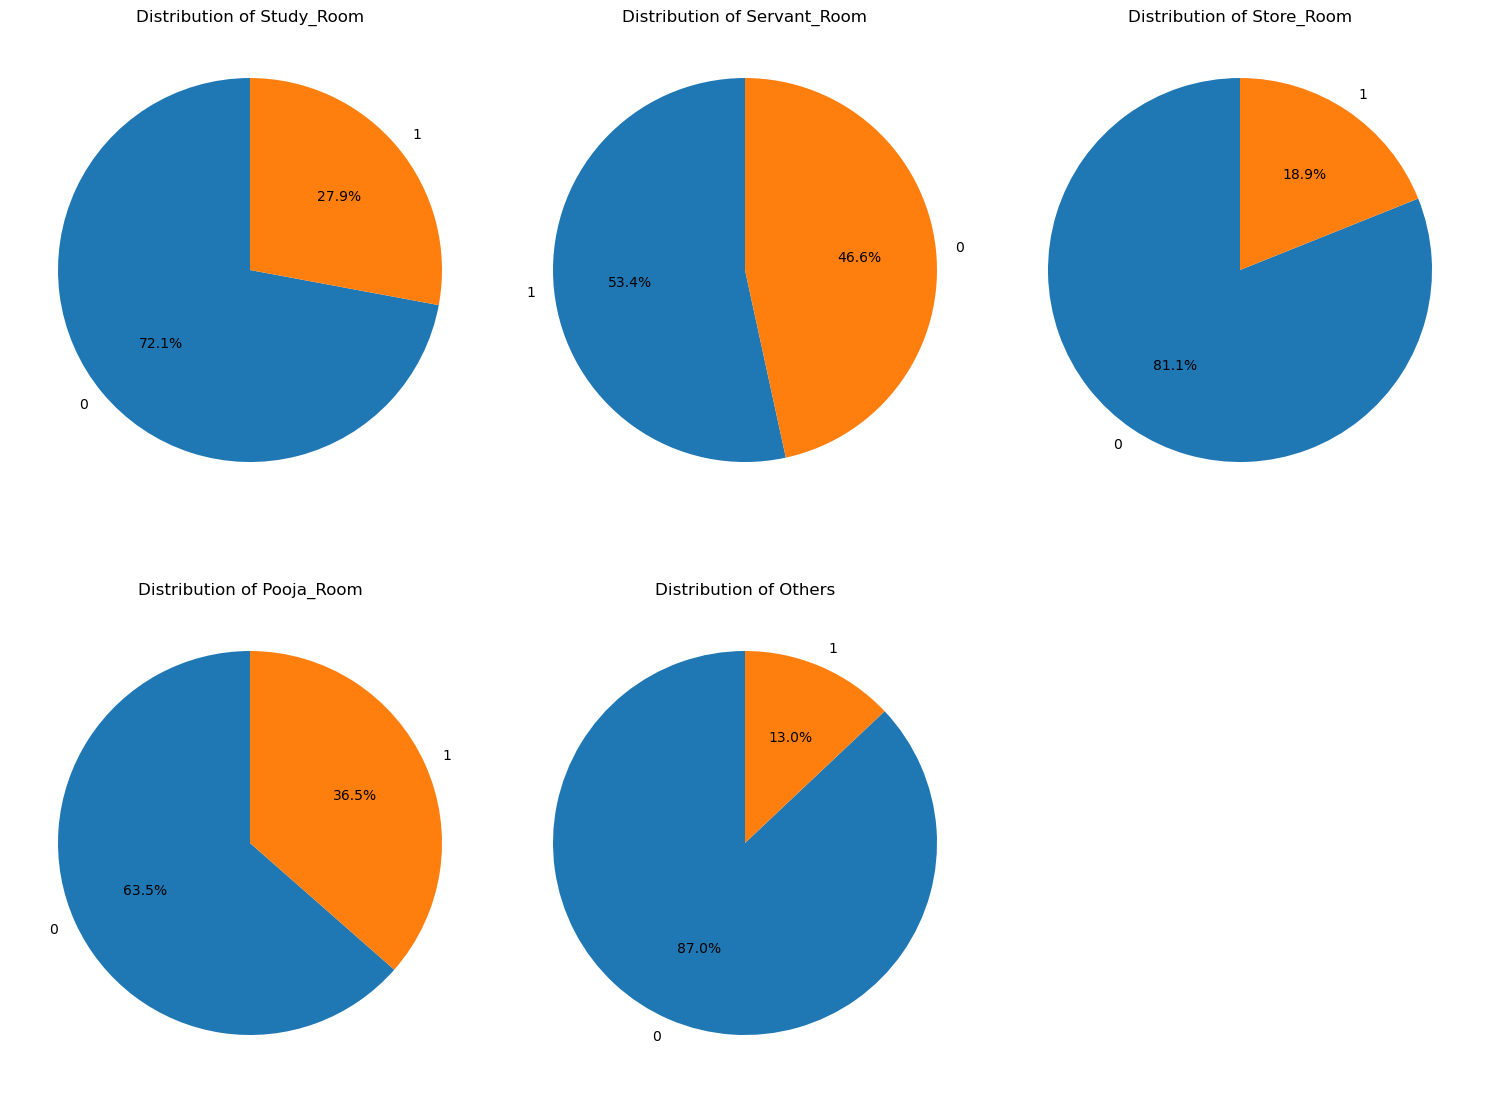

In [93]:
plt.figure(figsize=(15, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study_room','servant_room','store_room','pooja_room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    eda_univ[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### 14. furnishing_type

In [94]:
eda_univ['furnishing_type'].value_counts()

furnishing_type
Unfurnished       3796
Semi-Furnished    1711
Furnished          473
Name: count, dtype: int64

<Axes: ylabel='count'>

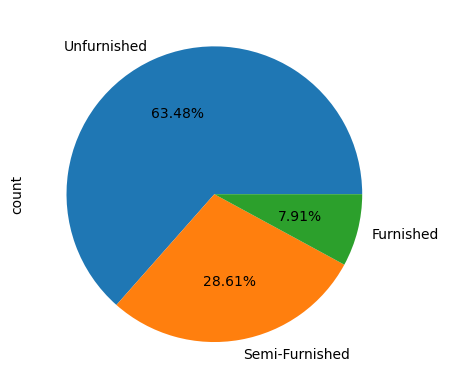

In [96]:
eda_univ['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [98]:
eda_univ.groupby("furnishing_type")["price_in_cr"].median()

furnishing_type
Furnished         4.90
Semi-Furnished    4.60
Unfurnished       2.75
Name: price_in_cr, dtype: float64

In [99]:
eda_univ.groupby("furnishing_type")["price_per_sqft"].median()

furnishing_type
Furnished         23504.0
Semi-Furnished    17619.0
Unfurnished       15000.0
Name: price_per_sqft, dtype: float64

### 15. luxury score

In [101]:
eda_univ

,property_id,property_type,link,society,sector,price_in_cr,price_per_sqft,areawithtype,plot_area,super_built_up_area,...,floornum,study_room,servant_room,store_room,pooja_room,others,facing,furnishing_type,age_possession_category,luxury_score
0,Z82002722,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,SS Linden Floors,sector 84,2.76,15333.0,1800 sqft (167.23 sqm) Carpet Area,NaN,NaN,...,4.0,0,0,0,0,1,north-east,Unfurnished,New Property,0.005538
1,P84485374,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,"Block E DLF City Phase 1, Gurgaon",sector 26,4.25,15741.0,"2,700 sqft (251 sqm) Carpet Area",NaN,NaN,...,1.0,0,0,0,0,0,not available,Unfurnished,New Property,0.000000
2,X83510988,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,"Sushant Lok Phase 1, Gurgaon",sector 43,5.25,13125.0,"4,000 sqft (372 sqm) Carpet Area",NaN,NaN,...,4.0,1,1,0,1,1,east,Furnished,Relatively New,0.002501
3,Q83709812,Independent House,https://www.99acres.com/4-bhk-bedroom-independ...,International City by SOBHA Phase 2,sector 109,9.00,20000.0,4500 sqft (418.06 sqm) Plot Area,4500.0,NaN,...,2.0,0,1,0,0,0,west,Unfurnished,Relatively New,0.003063
4,R84594132,Flat,https://www.99acres.com/3-bhk-bedroom-apartmen...,godrej meridien,sector 106,3.11,15534.0,"2,002 sqft (186 sqm) Built-up Area",NaN,NaN,...,3.0,0,1,0,0,0,east,Unfurnished,New Property,0.003411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5975,X84830390,Independent House,https://www.99acres.com/8-bhk-bedroom-independ...,"Sector 52, Gurgaon",sector 52,5.25,58333.0,900 sqft (83.61 sqm) Plot Area,900.0,NaN,...,4.0,0,0,0,1,0,north-east,Unfurnished,New Property,0.002046
5976,J85765480,Independent Builder Floor,https://www.99acres.com/3-bhk-bedroom-independ...,Whiteland Blissville,sector 76,2.15,13000.0,"1,656 sqft (154 sqm) Super Built-up Area",NaN,1656.0,...,2.0,0,0,0,0,0,north-east,Unfurnished,New Property,0.007125
5977,Y85077706,Independent Builder Floor,https://www.99acres.com/2-bhk-bedroom-independ...,Signature Global Park,sector 33,0.95,9277.0,"1,024 sqft (95 sqm) Super Built-up Area",NaN,1024.0,...,3.0,0,0,0,0,0,north-east,Unfurnished,New Property,0.010188
5978,K84552310,Independent Builder Floor,https://www.99acres.com/4-bhk-bedroom-independ...,Huda Flats,sector 57,3.50,13207.0,"2,650 sqft (246 sqm) Super Built-up Area",NaN,2650.0,...,4.0,0,1,0,1,0,east,Semi-Furnished,New Property,0.009143


In [102]:
eda_univ['luxury_score'].isnull().sum()

0

In [103]:
eda_univ['luxury_score'].describe()

count    5980.000000
mean        0.005330
std         0.003705
min         0.000000
25%         0.002109
50%         0.004608
75%         0.008518
max         0.012478
Name: luxury_score, dtype: float64

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



<Axes: xlabel='luxury_score', ylabel='Count'>

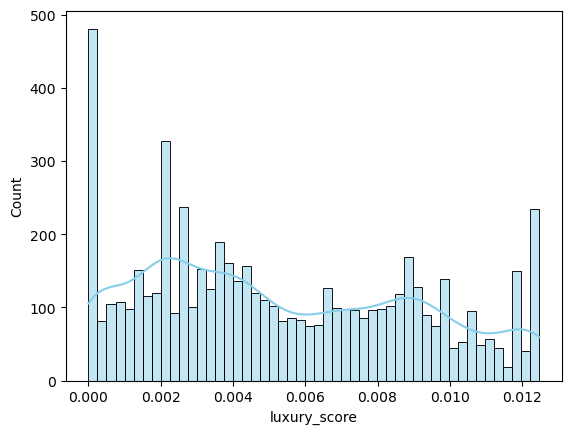

In [104]:
sns.histplot(eda_univ['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: xlabel='luxury_score'>

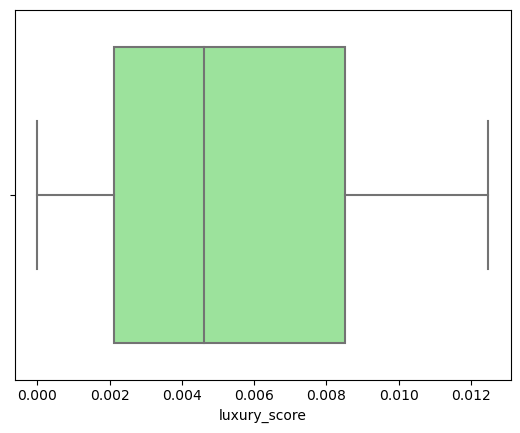

In [106]:
sns.boxplot(x= eda_univ['luxury_score'], color='lightgreen')

In [107]:
eda_univ.groupby(pd.qcut(eda_univ["luxury_score"], 4))["price_in_cr"].median()

C:\Users\Jay Patel\AppData\Local\Temp\ipykernel_15764\2892709992.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



luxury_score
(-0.001, 0.00211]     3.75
(0.00211, 0.00461]    3.20
(0.00461, 0.00852]    3.56
(0.00852, 0.0125]     3.35
Name: price_in_cr, dtype: float64

In [112]:
def compute_price_weighted_luxury_score(df):

    import ast
    from sklearn.preprocessing import MultiLabelBinarizer

    df = df.copy()

    # Step 1: Parse amenities
    df['features_list'] = df['features'].apply(
        lambda x: ast.literal_eval(x) if pd.notna(x) else []
    )

    # Step 2: Multi-hot encode
    mlb = MultiLabelBinarizer()
    binary_features = mlb.fit_transform(df['features_list'])

    features_encoded = pd.DataFrame(
        binary_features,
        columns=mlb.classes_,
        index=df.index
    )

    # Step 3: Compute price premium per amenity
    amenity_weights = {}

    for col in features_encoded.columns:

        present_mask = features_encoded[col] == 1
        absent_mask = features_encoded[col] == 0

        if present_mask.sum() > 30:  # Avoid very rare amenities

            median_present = df.loc[present_mask, 'price_per_sqft'].median()
            median_absent = df.loc[absent_mask, 'price_per_sqft'].median()

            premium = median_present - median_absent

            amenity_weights[col] = max(premium, 0)  # Ignore negative impact

        else:
            amenity_weights[col] = 0

    weights_series = pd.Series(amenity_weights)

    # Normalize weights
    if weights_series.max() > 0:
        weights_series = weights_series / weights_series.max()

    # Step 4: Compute final luxury score
    df['luxury_score_v2'] = np.log1p(
        features_encoded.mul(weights_series, axis=1).sum(axis=1)
    )

    return df

df = compute_price_weighted_luxury_score(eda_univ)

In [115]:
df.groupby(pd.qcut(df["luxury_score_v2"], 4), observed=True)["price_per_sqft"].median()

luxury_score_v2
(-0.001, 0.141]    14708.5
(0.141, 0.695]     15000.0
(0.695, 1.106]     19166.0
(1.106, 1.365]     17927.0
Name: price_per_sqft, dtype: float64

In [114]:
eda_univ.groupby(pd.qcut(eda_univ["luxury_score"], 4))["price_per_sqft"].median()

C:\Users\Jay Patel\AppData\Local\Temp\ipykernel_15764\3684591650.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



luxury_score
(-0.001, 0.00211]     20860.5
(0.00211, 0.00461]    14995.0
(0.00461, 0.00852]    16213.0
(0.00852, 0.0125]     15643.0
Name: price_per_sqft, dtype: float64